Solution with omega = 1.1 converged in 2950 iterations
Solution with omega = 1.3 converged in 2006 iterations
Solution with omega = 1.5 converged in 1297 iterations
Solution with omega = 1.7 converged in 736 iterations


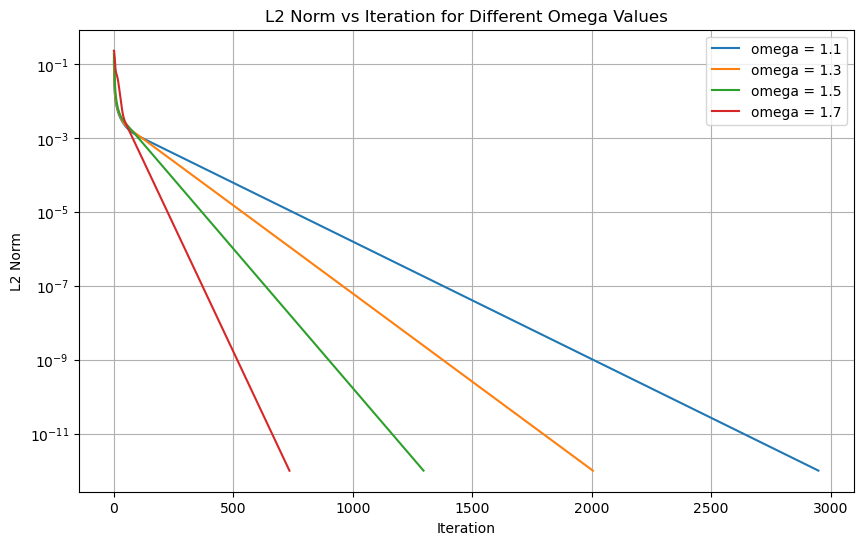

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 2.0, 1.0
nx, ny = 40, 20
dx, dy = Lx / nx, Ly / ny
tolerance = 1e-12

# Initialize temperature array including ghost cells
T = np.zeros((nx + 2, ny + 2))

# Function to set boundary conditions
def set_boundary_conditions(T, nx, ny, dx, dy):
    for i in range(1, nx + 1):  # Top boundary (y = 1)
        x = (i - 0.5) * dx
        T[i, ny + 1] = 2 * np.sin(np.pi * x / 2) - T[i, ny]

    for i in range(1, nx + 1):  # Bottom boundary (y = 0)
        T[i, 0] = T[i, 1]

    for j in range(1, ny + 1):  # Left boundary (x = 0)
        T[0, j] = -T[1, j]

    for j in range(1, ny + 1):  # Right boundary (x = Lx)
        T[nx + 1, j] = -T[nx, j]

    return T

# Gauss-Seidel iteration function with Successive Over-Relaxation (SOR)
def gauss_seidel_iteration_sor(T, nx, ny, omega):
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            T_new = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
            T[i, j] = (1 - omega) * T[i, j] + omega * T_new  # SOR update
    return T

# L2 norm calculation
def L2_normalization(T, old_T, nx, ny):
    diff = T[1:nx+1, 1:ny+1] - old_T[1:nx+1, 1:ny+1]
    return np.sqrt(np.sum(diff**2) / (nx * ny))

# Function to solve and track iterations and L2 norm
def solve_with_sor_and_track(omega):
    T = np.zeros((nx + 2, ny + 2))  # Reset temperature array
    T = set_boundary_conditions(T, nx, ny, dx, dy)
    iteration = 0
    L2_norm = 1e10
    L2_norms = []  # Track L2 norms for plotting
    while L2_norm > tolerance:
        old_T = T.copy()
        T = gauss_seidel_iteration_sor(T, nx, ny, omega)
        T = set_boundary_conditions(T, nx, ny, dx, dy)  # Reapply boundary conditions
        L2_norm = L2_normalization(T, old_T, nx, ny)
        L2_norms.append(L2_norm)
        iteration += 1
    return iteration, L2_norms, T

# Test for different omega values
omega_values = [1.1, 1.3,1.5,1.7]
results = {}
final_solutions = {}
for omega in omega_values:
    iter_count, L2_norms, final_T = solve_with_sor_and_track(omega)
    results[omega] = {
        "iterations": iter_count,
        "L2_norms": L2_norms
    }
    final_solutions[omega] = final_T
    print(f"Solution with omega = {omega} converged in {iter_count} iterations")

# Plot L2 norm for each omega
plt.figure(figsize=(10, 6))
for omega in omega_values:
    plt.plot(results[omega]["L2_norms"], label=f"omega = {omega}")

plt.yscale('log')  # Log scale to show small changes in L2 norm
plt.xlabel("Iteration")
plt.ylabel("L2 Norm")
plt.title("L2 Norm vs Iteration for Different Omega Values")
plt.legend()
plt.grid()
plt.show()

# Plotting function for solution
def plot_solution_midpoints(T, nx, ny, dx, dy, omega):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title(f"Numerical Solution with SOR (omega = {omega})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()



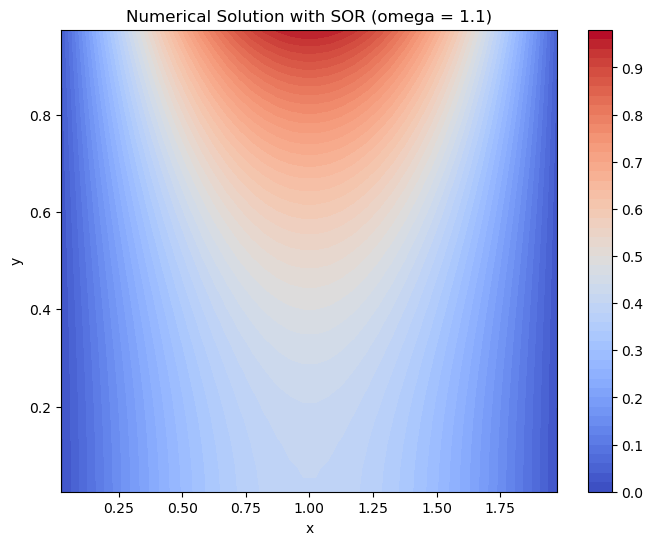

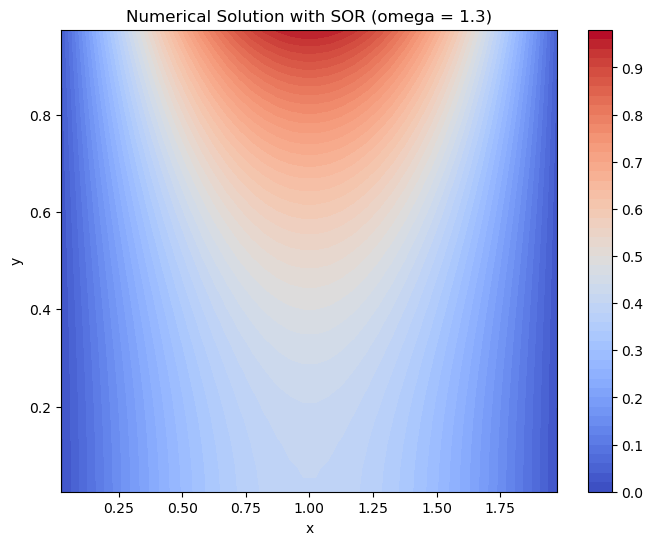

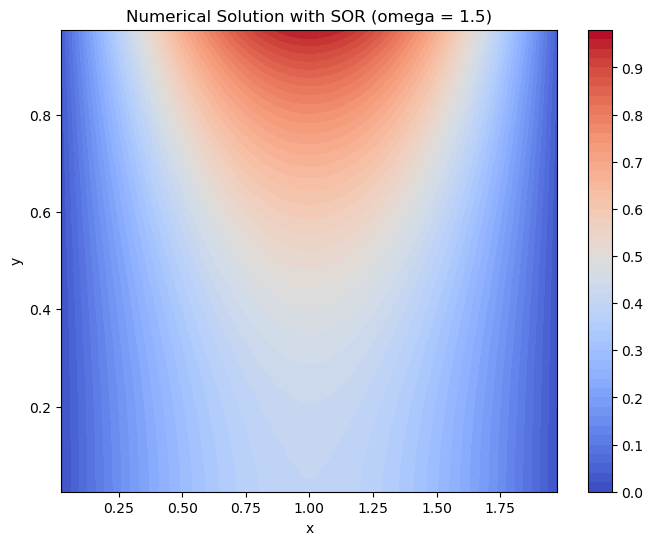

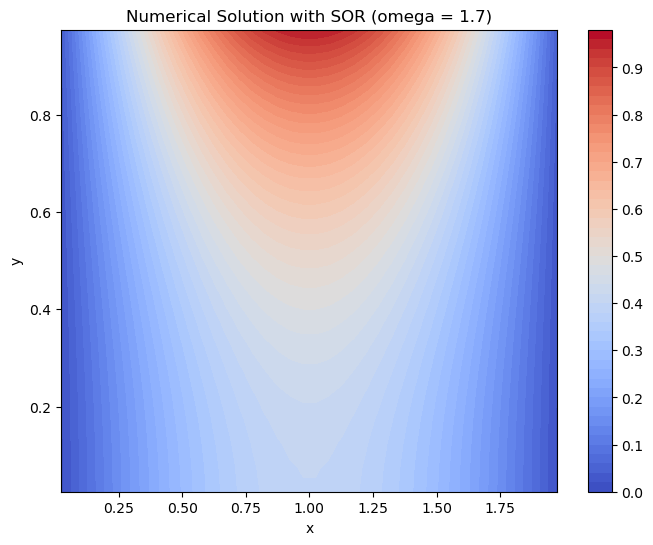

In [3]:
# Plot final solutions for each omega
for omega in omega_values:
    plot_solution_midpoints(final_solutions[omega], nx, ny, dx, dy, omega)